# Model Evaluation

### Objective

This notebook performs final evaluation of the selected SVM model
using the held-out test dataset.

The evaluation includes:

- Loading the final trained SVM pipeline
- Generating predictions and probability estimates
- Accuracy, precision, recall, F1-score, and ROC-AUC
- Confusion matrix analysis
- Sensitivity and specificity
- ROC and Precision-Recall curves
- False-positive and false-negative analysis
- Decision-threshold analysis
- Final assessment of model performance

The held-out test set is used only for final model evaluation and was
not used during feature selection or hyperparameter tuning.

In [1]:
### Import Necessary Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report)

In [2]:
### Load the dataset
df = pd.read_csv("D:/STUDY/Data_Science_Courses/PROJECTS/2.CancerGuard-SVM/CancerGuard---SVM-Cancer-Detection-API/data/Breast-Cancer_data.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
df_clean = df.drop(
    columns=["id", "Unnamed: 32"]
).copy()

df_clean["diagnosis"] = df_clean["diagnosis"].map({
    "B": 0,
    "M": 1
})

X = df_clean.drop(columns=["diagnosis"])
y = df_clean["diagnosis"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set    :", X_test.shape)

print("\nTest class distribution:")
print(y_test.value_counts().sort_index())

Training set: (455, 30)
Test set    : (114, 30)

Test class distribution:
diagnosis
0    72
1    42
Name: count, dtype: int64


### Step 1 — Load the final trained model

In [5]:
MODEL_PATH = "../models/final_svm_pipeline.pkl"

final_model = joblib.load(MODEL_PATH)

print("Final model loaded successfully.")
print()
print(final_model)

Final model loaded successfully.

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm',
                 SVC(C=10, class_weight='balanced', gamma=0.01,
                     probability=True, random_state=42))])


In [6]:
svm_model = final_model.named_steps["svm"]

print("Kernel       :", svm_model.kernel)
print("C            :", svm_model.C)
print("Gamma        :", svm_model.gamma)
print("Class Weight :", svm_model.class_weight)
print("Probability  :", svm_model.probability)

Kernel       : rbf
C            : 10
Gamma        : 0.01
Class Weight : balanced
Probability  : True


### Step 2 — Generate predictions

#### 2.1 — Class predictions

In [7]:
y_pred = final_model.predict(X_test)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

print("\nPredicted class distribution:")
print(pd.Series(y_pred).value_counts().sort_index())

Predictions generated successfully.
Number of predictions: 114

Predicted class distribution:
0    73
1    41
Name: count, dtype: int64


#### 2.2 — Probability estimates

In [9]:
y_proba = final_model.predict_proba(X_test)[:, 1]

print("Probability estimates generated.")
print("Number of probabilities:", len(y_proba))

print("\nFirst 10 malignant probabilities:")
print(np.round(y_proba[:10], 4))

Probability estimates generated.
Number of probabilities: 114

First 10 malignant probabilities:
[3.000e-04 1.000e+00 4.940e-02 5.426e-01 1.800e-01 4.800e-03 8.658e-01
 1.000e-03 4.000e-04 7.700e-03]


### Step 3 — Final test metrics

In [10]:
test_accuracy = accuracy_score(
    y_test,
    y_pred
)

test_precision = precision_score(
    y_test,
    y_pred
)

test_recall = recall_score(
    y_test,
    y_pred
)

test_f1 = f1_score(
    y_test,
    y_pred
)

test_roc_auc = roc_auc_score(
    y_test,
    y_proba
)

test_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall / Sensitivity",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        test_roc_auc
    ]
})

display(test_metrics)

,Metric,Score
0,Accuracy,0.991228
1,Precision,1.000000
2,Recall / Sensitivity,0.976190
3,F1 Score,0.987952
4,ROC-AUC,0.997024


In [11]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Benign",
            "Malignant"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

      Benign     0.9863    1.0000    0.9931        72
   Malignant     1.0000    0.9762    0.9880        42

    accuracy                         0.9912       114
   macro avg     0.9932    0.9881    0.9905       114
weighted avg     0.9913    0.9912    0.9912       114



### Step 4 — Confusion Matrix

In [12]:
cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)

print("\nBreakdown:")
print(f"True Negatives  (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives  (TP): {tp}")

Confusion Matrix:
[[72  0]
 [ 1 41]]

Breakdown:
True Negatives  (TN): 72
False Positives (FP): 0
False Negatives (FN): 1
True Positives  (TP): 41


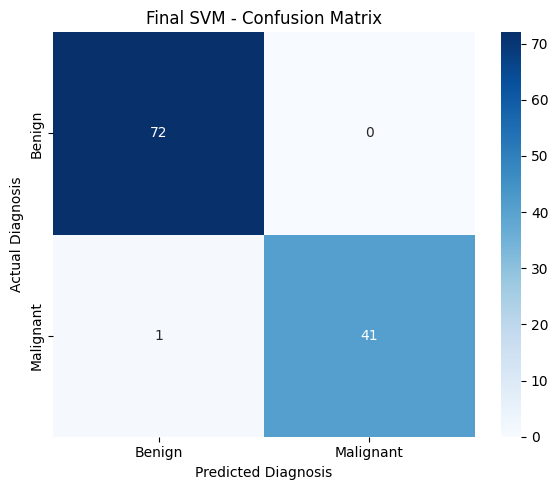

In [13]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.xlabel("Predicted Diagnosis")
plt.ylabel("Actual Diagnosis")
plt.title("Final SVM - Confusion Matrix")

plt.tight_layout()
plt.show()

### Step 5 — Sensitivity and Specificity

In [14]:
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0

clinical_metrics = pd.DataFrame({
    "Metric": [
        "Sensitivity (Recall)",
        "Specificity",
        "PPV (Precision)",
        "NPV"
    ],
    "Score": [
        sensitivity,
        specificity,
        ppv,
        npv
    ]
})

display(clinical_metrics)

,Metric,Score
0,Sensitivity (Recall),0.976190
1,Specificity,1.000000
2,PPV (Precision),1.000000
3,NPV,0.986301


### Step 6 — ROC Curve

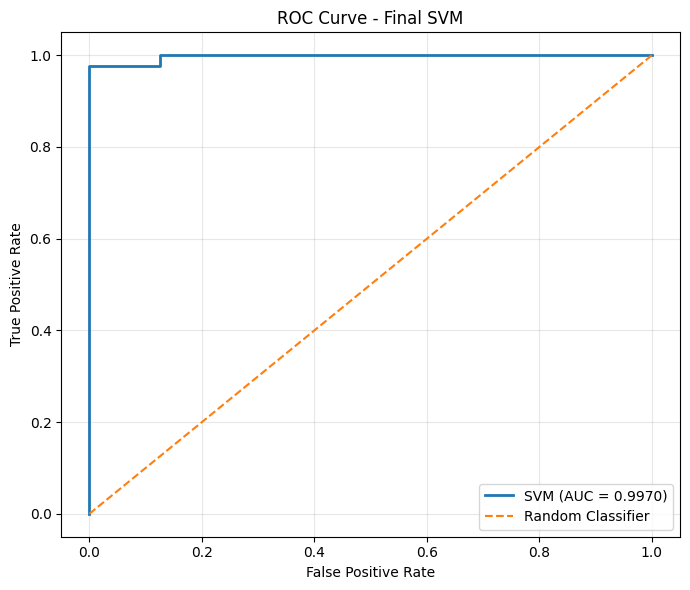

ROC-AUC: 0.997024


In [16]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    y_proba
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"SVM (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final SVM")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"ROC-AUC: {roc_auc:.6f}")

### Step 7 — Precision-Recall Curve

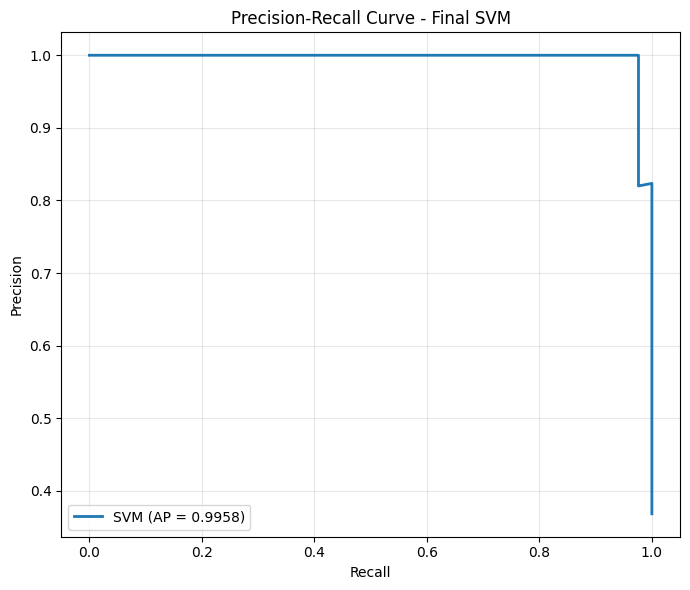

Average Precision (PR-AUC): 0.995798


In [17]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

precision_curve, recall_curve, pr_thresholds = (
    precision_recall_curve(
        y_test,
        y_proba
    )
)

average_precision = average_precision_score(
    y_test,
    y_proba
)

plt.figure(figsize=(7, 6))

plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label=f"SVM (AP = {average_precision:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Final SVM")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(
    f"Average Precision (PR-AUC): "
    f"{average_precision:.6f}"
)

### Step 8 — Error Analysis

In [18]:
evaluation_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Malignant_Probability": y_proba
}, index=X_test.index)

evaluation_results["Correct"] = (
    evaluation_results["Actual"] ==
    evaluation_results["Predicted"]
)

print("Total test cases:", len(evaluation_results))
print("Correct predictions:", evaluation_results["Correct"].sum())
print("Incorrect predictions:", (~evaluation_results["Correct"]).sum())

display(evaluation_results.head(10))

Total test cases: 114
Correct predictions: 113
Incorrect predictions: 1


,Actual,Predicted,Malignant_Probability,Correct
120,0,0,0.000255,True
250,1,1,1.000000,True
375,0,0,0.049391,True
99,1,1,0.542556,True
455,0,0,0.180040,True
318,0,0,0.004824,True
39,1,1,0.865792,True
371,0,0,0.001025,True
98,0,0,0.000431,True
502,0,0,0.007719,True


#### Step 8.1 — Extract all misclassified cases

In [19]:
misclassified = evaluation_results[
    evaluation_results["Correct"] == False
].copy()

print("Number of misclassified cases:", len(misclassified))

display(misclassified)

Number of misclassified cases: 1


,Actual,Predicted,Malignant_Probability,Correct
73,1,0,0.051413,False


#### 8.2 — Separate FP and FN

In [20]:
false_positives = evaluation_results[
    (evaluation_results["Actual"] == 0) &
    (evaluation_results["Predicted"] == 1)
]

false_negatives = evaluation_results[
    (evaluation_results["Actual"] == 1) &
    (evaluation_results["Predicted"] == 0)
]

print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))

print("\nFalse Negative case(s):")
display(false_negatives)

False Positives: 0
False Negatives: 1

False Negative case(s):


,Actual,Predicted,Malignant_Probability,Correct
73,1,0,0.051413,False


### Step 9 — Inspect the False Negative

In [21]:
fn_indices = false_negatives.index

fn_features = X_test.loc[fn_indices].copy()

fn_features["Actual"] = y_test.loc[fn_indices]
fn_features["Predicted"] = y_pred[
    [X_test.index.get_loc(i) for i in fn_indices]
]

fn_features["Malignant_Probability"] = false_negatives[
    "Malignant_Probability"
]

display(fn_features.T)

,73
radius_mean,13.800000
texture_mean,15.790000
perimeter_mean,90.430000
area_mean,584.100000
smoothness_mean,0.100700
compactness_mean,0.128000
concavity_mean,0.077890
concave points_mean,0.050690
symmetry_mean,0.166200
fractal_dimension_mean,0.065660


#### Step 10 — Probability Distribution

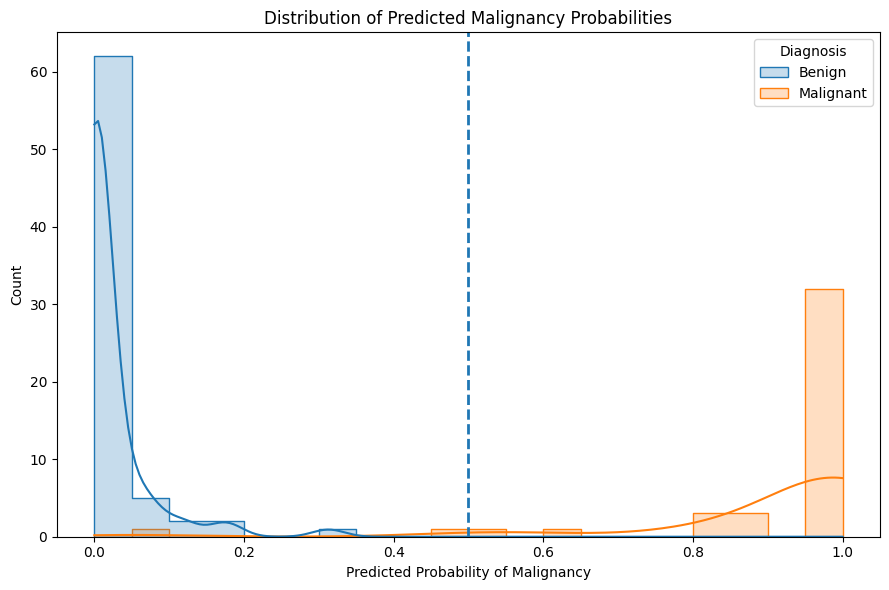

In [ ]:
##  PROBABILITY DISTRIBUTION BY ACTUAL CLASS
probability_df = pd.DataFrame({
    "Actual_Class": y_test.values,
    "Malignant_Probability": y_proba
})

probability_df["Diagnosis"] = probability_df[
    "Actual_Class"
].map({
    0: "Benign",
    1: "Malignant"
})

plt.figure(figsize=(9, 6))

sns.histplot(
    data=probability_df,
    x="Malignant_Probability",
    hue="Diagnosis",
    bins=20,
    kde=True,
    element="step"
)

plt.axvline(
    0.5,
    linestyle="--",
    linewidth=2,
    label="Threshold = 0.50"
)

plt.xlabel("Predicted Probability of Malignancy")
plt.ylabel("Count")
plt.title("Distribution of Predicted Malignancy Probabilities")

plt.tight_layout()
plt.show()

In [24]:
## PROBABILITY SUMMARY

probability_summary = (
    probability_df
    .groupby("Diagnosis")["Malignant_Probability"]
    .agg([
        "count",
        "min",
        "mean",
        "median",
        "max"
    ])
)
display(probability_summary)

,count,min,mean,median,max
Diagnosis,,,,,
Benign,72,0.000010,0.021498,0.001706,0.312911
Malignant,42,0.051413,0.918640,0.995653,1.000000


### Step 11 — Threshold Analysis

In [25]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.base import clone

# Same CV strategy used during model development
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Clone final model so the already-fitted model is untouched
threshold_model = clone(final_model)

# Generate out-of-fold probabilities ONLY from training data
y_train_oof_prob = cross_val_predict(
    threshold_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print("OOF probabilities generated successfully.")
print("Number of training observations:", len(y_train_oof_prob))

print("\nProbability range:")
print(f"Minimum: {y_train_oof_prob.min():.6f}")
print(f"Maximum: {y_train_oof_prob.max():.6f}")

OOF probabilities generated successfully.
Number of training observations: 455

Probability range:
Minimum: 0.000019
Maximum: 1.000000


#### 11.1 — Evaluate Candidate Thresholds on OOF Training Predictions

In [26]:
# Candidate thresholds
thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:

    # Convert probabilities into class predictions
    y_pred_threshold = (
        y_train_oof_prob >= threshold
    ).astype(int)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_train,
        y_pred_threshold
    ).ravel()

    # Metrics
    accuracy = accuracy_score(
        y_train,
        y_pred_threshold
    )

    precision = precision_score(
        y_train,
        y_pred_threshold,
        zero_division=0
    )

    sensitivity = recall_score(
        y_train,
        y_pred_threshold
    )

    specificity = tn / (tn + fp)

    f1 = f1_score(
        y_train,
        y_pred_threshold
    )

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "F1": f1,
        "False_Positives": fp,
        "False_Negatives": fn
    })


threshold_results_df = pd.DataFrame(
    threshold_results
)

# Cleaner display
threshold_results_df["Threshold"] = (
    threshold_results_df["Threshold"].round(2)
)

display(
    threshold_results_df.round(4)
)

,Threshold,Accuracy,Precision,Sensitivity,Specificity,F1,False_Positives,False_Negatives
0,0.10,0.9363,0.8579,0.9941,0.9018,0.9210,28,1
1,0.15,0.9516,0.8936,0.9882,0.9298,0.9385,20,2
2,0.20,0.9560,0.9032,0.9882,0.9368,0.9438,18,2
3,0.25,0.9648,0.9278,0.9824,0.9544,0.9543,13,3
4,0.30,0.9692,0.9382,0.9824,0.9614,0.9598,11,3
5,0.35,0.9714,0.9538,0.9706,0.9719,0.9621,8,5
6,0.40,0.9714,0.9591,0.9647,0.9754,0.9619,7,6
7,0.45,0.9780,0.9819,0.9588,0.9895,0.9702,3,7
8,0.50,0.9802,0.9879,0.9588,0.9930,0.9731,2,7
9,0.55,0.9802,0.9879,0.9588,0.9930,0.9731,2,7


#### Step 11.2 — Select Threshold Using a Sensitivity Constraint

In [27]:
MIN_SENSITIVITY = 0.98

eligible_thresholds = threshold_results_df[
    threshold_results_df["Sensitivity"] >= MIN_SENSITIVITY
].copy()

print(
    f"Thresholds satisfying minimum sensitivity "
    f"({MIN_SENSITIVITY:.0%}):"
)

display(
    eligible_thresholds.sort_values(
        ["Specificity", "F1"],
        ascending=[False, False]
    ).round(4)
)

# Select highest specificity among thresholds
# satisfying the sensitivity requirement
best_threshold_row = (
    eligible_thresholds
    .sort_values(
        ["Specificity", "F1"],
        ascending=[False, False]
    )
    .iloc[0]
)

selected_threshold = float(
    best_threshold_row["Threshold"]
)

print("\nSelected operating threshold:")
print(f"Threshold   : {selected_threshold:.2f}")
print(
    f"Sensitivity : "
    f"{best_threshold_row['Sensitivity']:.4f}"
)
print(
    f"Specificity : "
    f"{best_threshold_row['Specificity']:.4f}"
)
print(
    f"Precision   : "
    f"{best_threshold_row['Precision']:.4f}"
)
print(
    f"F1          : "
    f"{best_threshold_row['F1']:.4f}"
)
print(
    f"False Positives : "
    f"{int(best_threshold_row['False_Positives'])}"
)
print(
    f"False Negatives : "
    f"{int(best_threshold_row['False_Negatives'])}"
)

Thresholds satisfying minimum sensitivity (98%):


,Threshold,Accuracy,Precision,Sensitivity,Specificity,F1,False_Positives,False_Negatives
4,0.30,0.9692,0.9382,0.9824,0.9614,0.9598,11,3
3,0.25,0.9648,0.9278,0.9824,0.9544,0.9543,13,3
2,0.20,0.9560,0.9032,0.9882,0.9368,0.9438,18,2
1,0.15,0.9516,0.8936,0.9882,0.9298,0.9385,20,2
0,0.10,0.9363,0.8579,0.9941,0.9018,0.9210,28,1



Selected operating threshold:
Threshold   : 0.30
Sensitivity : 0.9824
Specificity : 0.9614
Precision   : 0.9382
F1          : 0.9598
False Positives : 11
False Negatives : 3


#### 11.3 — Generate Test Probabilities

In [30]:
y_test_prob = final_model.predict_proba(X_test)[:, 1]

print("Test probabilities generated successfully.")
print("Number of probabilities:", len(y_test_prob))
print(f"Minimum probability: {y_test_prob.min():.6f}")
print(f"Maximum probability: {y_test_prob.max():.6f}")

Test probabilities generated successfully.
Number of probabilities: 114
Minimum probability: 0.000010
Maximum probability: 1.000000


#### 11.4 — Final Test Evaluation at Locked Threshold 0.30

In [31]:

# ------------------------------------------------------------
# 1. Use threshold selected ONLY from OOF training predictions
# ------------------------------------------------------------

LOCKED_THRESHOLD = selected_threshold

y_test_pred_030 = (
    y_test_prob >= LOCKED_THRESHOLD
).astype(int)


# ------------------------------------------------------------
# 2. Confusion matrix
# ------------------------------------------------------------

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_test_pred_030
).ravel()


# ------------------------------------------------------------
# 3. Calculate metrics
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_test_pred_030
)

precision = precision_score(
    y_test,
    y_test_pred_030,
    zero_division=0
)

sensitivity = recall_score(
    y_test,
    y_test_pred_030
)

specificity = tn / (tn + fp)

f1 = f1_score(
    y_test,
    y_test_pred_030
)


# ------------------------------------------------------------
# 4. Display results
# ------------------------------------------------------------

print(f"Locked threshold: {LOCKED_THRESHOLD:.2f}")

print("\nFinal test confusion matrix:")
print(f"TN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")

print("\nFinal test performance:")
print(f"Accuracy    : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Sensitivity : {sensitivity:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"F1 Score    : {f1:.4f}")

Locked threshold: 0.30

Final test confusion matrix:
TN: 71
FP: 1
FN: 1
TP: 41

Final test performance:
Accuracy    : 0.9825
Precision   : 0.9762
Sensitivity : 0.9762
Specificity : 0.9861
F1 Score    : 0.9762


#### 11.5 — Compare Default 0.50 vs Selected 0.30

In [32]:
def evaluate_threshold(y_true, probabilities, threshold):

    predictions = (
        probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions
    ).ravel()

    return {
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_true, predictions
        ),
        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "Sensitivity": recall_score(
            y_true,
            predictions
        ),
        "Specificity": tn / (tn + fp),
        "F1": f1_score(
            y_true,
            predictions
        ),
        "False_Positives": fp,
        "False_Negatives": fn
    }


comparison = pd.DataFrame([
    evaluate_threshold(
        y_test,
        y_test_prob,
        0.50
    ),

    evaluate_threshold(
        y_test,
        y_test_prob,
        LOCKED_THRESHOLD
    )
])

comparison["Model"] = [
    "Default Threshold",
    "Selected Threshold"
]

comparison = comparison[
    [
        "Model",
        "Threshold",
        "Accuracy",
        "Precision",
        "Sensitivity",
        "Specificity",
        "F1",
        "False_Positives",
        "False_Negatives"
    ]
]

display(
    comparison.round(4)
)

,Model,Threshold,Accuracy,Precision,Sensitivity,Specificity,F1,False_Positives,False_Negatives
0,Default Threshold,0.5,0.9825,1.0000,0.9524,1.0000,0.9756,0,2
1,Selected Threshold,0.3,0.9825,0.9762,0.9762,0.9861,0.9762,1,1


### Final Operating Threshold Selection

The classification threshold was selected using out-of-fold (OOF)
probability estimates generated exclusively from the training set,
preventing test-set information from influencing threshold optimization.

A minimum malignant sensitivity criterion of 98% was applied to the
OOF training predictions. Among thresholds satisfying this criterion,
0.30 achieved the highest specificity and was therefore selected as
the operating threshold.

On the independent test set, the selected threshold of 0.30 achieved:

- Accuracy: 98.25%
- Precision (PPV): 97.62%
- Sensitivity (Recall): 97.62%
- Specificity: 98.61%
- F1 Score: 97.62%
- False Positives: 1
- False Negatives: 1

Compared with a probability threshold of 0.50, the selected threshold
reduced false negatives from 2 to 1 while maintaining the same overall
accuracy, at the cost of one additional false positive.

The 0.30 threshold is therefore retained as the experimental operating
threshold for the CancerGuard prototype. This threshold is not a
clinically validated diagnostic cutoff and would require external
validation before any clinical use.